In [1]:
import numpy as np
import networkx as nx

import os

%load_ext autoreload
%autoreload 2

In [2]:
Graphs = np.load("networks/powerlaw_m=1_p=0.2/graphs.npy", allow_pickle=True)
G = Graphs[9]

## Load results

In [3]:
results_dir = "hierarchical_metadata_20"

In [22]:
from Qommunity.searchers.utils import HierarchicalRunMetadata


num_runs = 20

hierarchical_metadatas = []


for iter in range(num_runs):
    base_filename = f"{results_dir}/_{iter}" # I saved it with such prefix
    hm = HierarchicalRunMetadata.load_from_files(base_filename)
    hierarchical_metadatas.append(hm)

Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
DWave sampleset info loaded.
Embeddings info loaded
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
DWave sampleset info loaded.
Embeddings info loaded
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
DWave sampleset info loaded.
Embeddings info loaded
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
DWave sampleset info loaded.
Embeddings info loaded
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
DWave sampleset info loaded.
Embeddings info loaded
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
DWave sampleset info

In [23]:
import numpy as np


communities = np.load(f"{results_dir}/_communities.npy", allow_pickle=True)
division_modularities = np.load(f"{results_dir}/_division_modularities.npy", allow_pickle=True)
division_trees = np.load(f"{results_dir}/_division_trees.npy", allow_pickle=True)
modularities = np.load(f"{results_dir}/_modularities.npy", allow_pickle=True)

In [25]:
mods = []
cbf_max = []
cbf_avg = []
max_cbf_div_mod = []
chain_strengths = []
comms_lens = []
energies = []
indices = []

for idx, sm in enumerate(hierarchical_metadatas):
    cbf_max.append(np.array(sm.chain_break_fraction).max())
    cbf_avg.append(np.array(sm.chain_break_fraction).mean())
    i = np.array(sm.chain_break_fraction).argmax()
    indices.append(i)

    chain_strengths.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
    mods.append(modularities[idx])
    max_cbf_div_mod.append(division_modularities[idx][i+1])
    comms_lens.append(communities[idx])

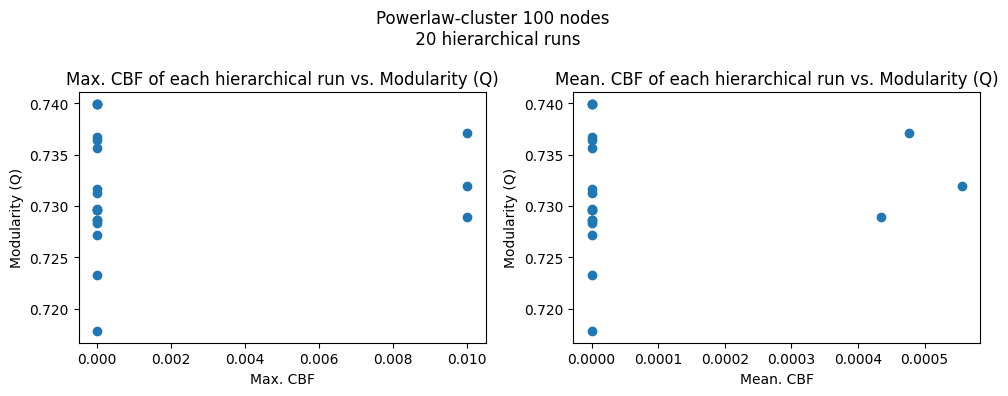

In [27]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Powerlaw-cluster 100 nodes \n 20 hierarchical runs")

ax[0].scatter(cbf_max, mods)
ax[0].set_ylabel("Modularity (Q)")
ax[0].set_xlabel("Max. CBF")
ax[0].set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");

ax[1].scatter(cbf_avg, mods)
ax[1].set_ylabel("Modularity (Q)")
ax[1].set_xlabel("Mean. CBF")
ax[1].set_title("Mean. CBF of each hierarchical run vs. Modularity (Q)");

plt.tight_layout()
plt.show()